# Mini Project: Deep Learning with Keras

In this mini-project we'll be building a deep learning classifier using Keras to predict income from the popular [Adult Income dataset](http://www.cs.toronto.edu/~delve/data/adult/adultDetail.html).

Predicting income from demographic and socio-economic information is an important task with real-world applications, such as financial planning, market research, and social policy analysis.

Here's a brief outline of what we will cover:
1. **Data Preprocessing**
2. **Building the Deep Learning Model**
3. **Model Training**
4. **Model Evaluation**

In [1]:
pip install scikeras

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

2026-03-28 13:00:39.532574: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/mohangajendra/Library/Python/3.8/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Task 1: Load the Adult Dataset

1. Load the Adult data into a Pandas Dataframe.
2. Ensure the dataset has properly named columns.
3. Display the first five rows of the dataset.

In [3]:
DATA_PATH = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

# Column names from the UCI documentation
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# The dataset uses '?' for missing values; sep handles leading spaces after commas
df = pd.read_csv(
    DATA_PATH,
    names=column_names,
    sep=r',\s*',
    engine='python',
    na_values='?'
)

print(f'Dataset loaded! Shape: {df.shape}')

Dataset loaded! Shape: (32561, 15)


In [4]:
# Display the first few rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Task 2: Exploratory Data Analysis, Drop NULLs, Encode Target

In [5]:
# EDA
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values (NaN) ===')
# The raw file uses '?' which we converted to NaN on load
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'Total rows with at least one missing value: {df.isnull().any(axis=1).sum():,}')

print('\n=== Target Distribution (income) ===')
income_pct = df['income'].value_counts(normalize=True) * 100
print(df['income'].value_counts())
print(f"\nPositive class (>50K) percentage: {income_pct.get('>50K', income_pct.iloc[1]):.2f}%")

print('\n=== Numeric Summary ===')
df.describe()

=== Shape ===
Rows: 32,561   Columns: 15

=== Data Types ===
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

=== Missing Values (NaN) ===
workclass         1836
occupation        1843
native-country     583
dtype: int64
Total rows with at least one missing value: 2,399

=== Target Distribution (income) ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Positive class (>50K) percentage: 24.08%

=== Numeric Summary ===


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Drop all rows with NULL values
print(f'Shape before dropping NaNs: {df.shape}')
df = df.dropna()
print(f'Shape after  dropping NaNs: {df.shape}')

Shape before dropping NaNs: (32561, 15)
Shape after  dropping NaNs: (30162, 15)


In [7]:
# Use LabelEncoder to convert income (string) to binary 0/1
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

print('Encoding mapping:')
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'  "{cls}" -> {enc}')
print(f'\nPositive rate (>50K): {df["income"].mean():.2%}')

Encoding mapping:
  "<=50K" -> 0
  ">50K" -> 1

Positive rate (>50K): 24.89%


## Task 3: Train/Test Split

In [8]:
X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserve class balance
)

print(f'Train: X={X_train.shape}  y={y_train.shape}')
print(f'Test:  X={X_test.shape}   y={y_test.shape}')
print(f'Positive rate - train: {y_train.mean():.2%}  test: {y_test.mean():.2%}')

Train: X=(24129, 14)  y=(24129,)
Test:  X=(6033, 14)   y=(6033,)
Positive rate - train: 24.89%  test: 24.90%


## Task 4: Baseline AUC (Always Predict Majority Class)

In [9]:
# Majority class is 0 (<=50K)
majority_class = int(y_train.mode()[0])
print(f'Majority class: {majority_class}  (0=<=50K, 1=>50K)')

y_pred_majority = np.full(len(y_test), majority_class)
baseline_auc = roc_auc_score(y_test, y_pred_majority)

print(f'Baseline AUC (always predict majority class): {baseline_auc:.4f}')
print('An AUC of 0.5 = no better than random guessing. This is the bar to beat.')

Majority class: 0  (0=<=50K, 1=>50K)
Baseline AUC (always predict majority class): 0.5000
An AUC of 0.5 = no better than random guessing. This is the bar to beat.


## Task 5: Feature Engineering with ColumnTransformer

In [10]:
categorical_features = [
    'workclass', 'education', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'native-country'
]
continuous_features = [c for c in X_train.columns if c not in categorical_features]

print('Continuous features:', continuous_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('scaler',  MinMaxScaler(), continuous_features)
    ],
    remainder='drop'
)
print('\nColumnTransformer ready.')

Continuous features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

ColumnTransformer ready.


In [11]:
# How many columns after transformation?
preprocessor.fit(X_train)

ohe = preprocessor.named_transformers_['onehot']
n_ohe_cols        = sum(len(cats) for cats in ohe.categories_)
n_continuous_cols = len(continuous_features)
total_cols        = n_ohe_cols + n_continuous_cols

print(f'OHE columns:        {n_ohe_cols}')
print(f'Continuous columns: {n_continuous_cols}')
print(f'Total output cols:  {total_cols}')

# Verify
X_check = preprocessor.transform(X_train)
print(f'\nVerification array shape: {X_check.shape}  (matches: {X_check.shape[1] == total_cols})')

OHE columns:        98
Continuous columns: 6
Total output cols:  104

Verification array shape: (24129, 104)  (matches: True)


## Task 6: Build, Train and Evaluate the Keras Model

In [12]:
# ── Task 6.1: Define the Keras model ─────────────────────────────────────────
#
# Binary classification => loss = 'binary_crossentropy', output = sigmoid.
# Start simple: two hidden layers + Dropout for regularization.

def build_model(n_features=108):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(n_features,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')   # single output, probability of >50K
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',   # correct loss for binary classification
        metrics=['accuracy']
    )
    return model

build_model(total_cols).summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6720      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 8833 (34.50 KB)
Trainable params: 8833 (34.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
# ── Task 6.2: Wrap with KerasClassifier ──────────────────────────────────────
keras_clf = KerasClassifier(
    model=build_model,
    n_features=total_cols,
    epochs=20,
    batch_size=64,
    verbose=0
)
print('KerasClassifier created.')

KerasClassifier created.


In [14]:
# ── Task 6.3: Build sklearn Pipeline ─────────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   keras_clf)
])
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country']),
                                                 ('scaler', MinMaxScaler(),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                      

In [15]:
# ── Task 6.4: Fit the pipeline ────────────────────────────────────────────────
print('Training...')
pipeline.fit(X_train, y_train)
print('Done!')

Training...
Done!


In [16]:
# ── Task 6.5: Calculate AUC on test set ──────────────────────────────────────
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]   # P(income > 50K)
model_auc    = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print(f'  Baseline AUC (majority class):  {baseline_auc:.4f}')
print(f'  Deep Learning Model AUC:        {model_auc:.4f}')
print('=' * 45)

if model_auc > baseline_auc:
    print(f'\nThe model predicts BETTER than random!')
    print(f'Improvement: +{model_auc - baseline_auc:.4f}')
else:
    print('Model does not beat baseline — try more epochs or deeper architecture.')

if model_auc >= 0.9:
    print('Excellent performance (AUC >= 0.9)')
elif model_auc >= 0.7:
    print('Good to excellent performance (0.7 <= AUC < 0.9)')
elif model_auc > 0.5:
    print('Poor to fair performance (0.5 < AUC < 0.7)')

  Baseline AUC (majority class):  0.5000
  Deep Learning Model AUC:        0.9061

The model predicts BETTER than random!
Improvement: +0.4061
Excellent performance (AUC >= 0.9)


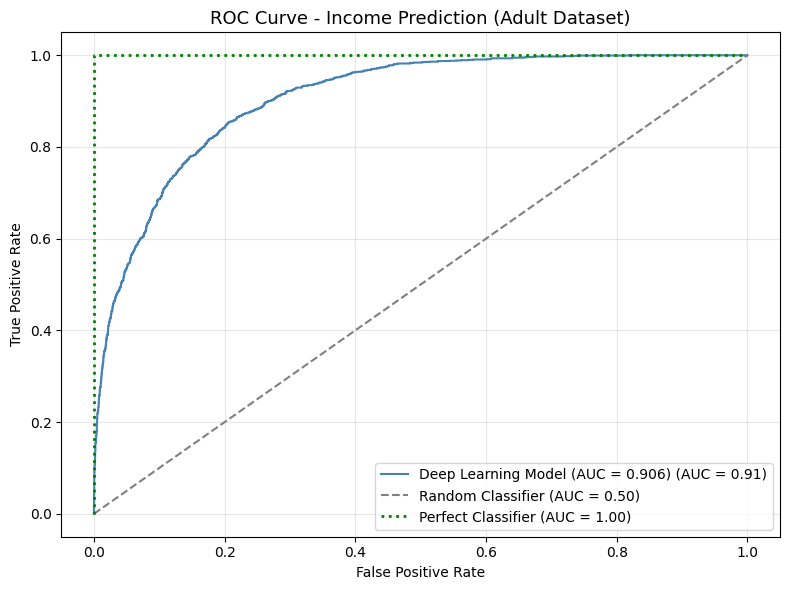


ROC Curve Interpretation:
  Gray dashed diagonal = random classifier (AUC=0.5)
  Each threshold gives the same FPR/TPR trade-off as a coin flip.

  Green dotted L-shape = perfect classifier (AUC=1.0)
  Hugs the top-left corner: 100% TPR at 0% FPR across all thresholds.

  Blue curve = our model
  The further it bows toward the top-left, the better.


In [17]:
# ── Task 6.6: ROC Curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f'Deep Learning Model (AUC = {model_auc:.3f})',
    color='steelblue', ax=ax
)

# Random classifier reference
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5,
        label='Random Classifier (AUC = 0.50)')

# Perfect classifier reference
ax.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='green', linewidth=2,
        label='Perfect Classifier (AUC = 1.00)')

ax.set_title('ROC Curve - Income Prediction (Adult Dataset)', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('ROC Curve Interpretation:')
print('  Gray dashed diagonal = random classifier (AUC=0.5)')
print('  Each threshold gives the same FPR/TPR trade-off as a coin flip.')
print()
print('  Green dotted L-shape = perfect classifier (AUC=1.0)')
print('  Hugs the top-left corner: 100% TPR at 0% FPR across all thresholds.')
print()
print('  Blue curve = our model')
print('  The further it bows toward the top-left, the better.')